In [1]:
import pymc as pm
import numpy as np

from IPython.core.pylabtools import figsize
import matplotlib.pyplot as plt
import scipy.stats as stats
import arviz as az

plt.style.use("ggplot")

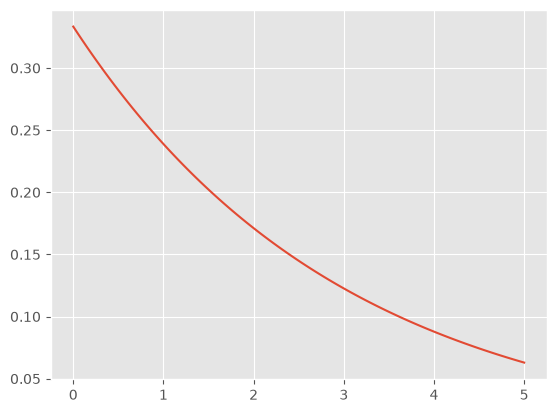

In [2]:
x = y = np.linspace(0, 5, 100)
exp_x = stats.expon.pdf(x, scale=3)
plt.plot(x, exp_x)
plt.show()

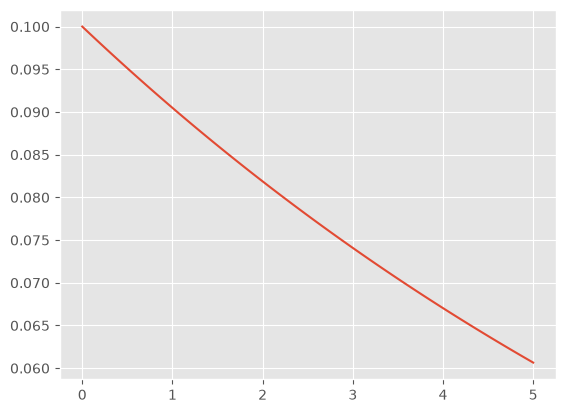

In [3]:
exp_y = stats.expon.pdf(x, scale=10)
plt.plot(x, exp_y)
plt.show()

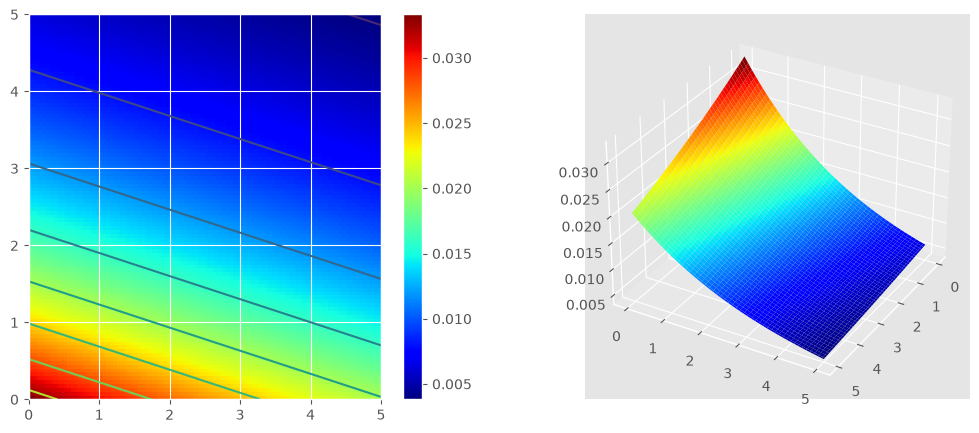

In [4]:
figsize(12.5, 5)
fig = plt.figure()
plt.subplot(121)

X, Y = np.meshgrid(x, y)

M = np.dot(exp_x[:, None], exp_y[None, :])
CS = plt.contour(X, Y, M)
plt.imshow(M, origin='lower', aspect='auto', cmap='jet', extent=(0, 5, 0, 5))
plt.colorbar()

ax = fig.add_subplot(122, projection='3d')
ax.plot_surface(X, Y, M, cmap='jet')
ax.view_init(azim=390)

observed (2-dimensional,sample size = 5): [[0 2]
 [3 3]
 [0 4]
 [1 2]
 [2 3]]


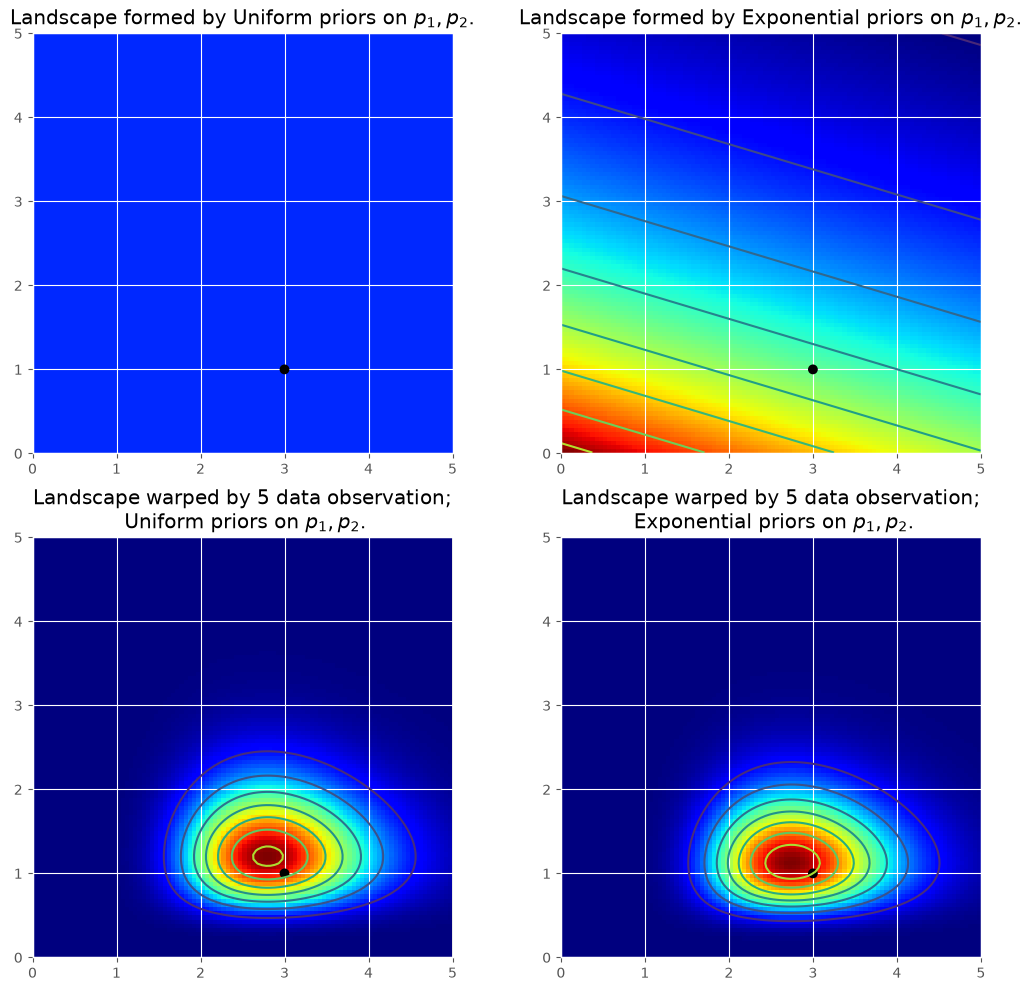

In [11]:
# create the observed data

# sample size of data we observe, trying varying this (keep it less than 100 ;)
N = 5

# the true parameters, but of course we do not see these values...
lambda_1_true = 1
lambda_2_true = 3

#...we see the data generated, dependent on the above two values.
data = np.concatenate([
    stats.poisson.rvs(lambda_1_true, size=(N, 1)),
    stats.poisson.rvs(lambda_2_true, size=(N, 1))
], axis=1)
print("observed (2-dimensional,sample size = %d):" % N, data)

# plotting details.
x = y = np.linspace(.01, 5, 100)
likelihood_x = np.array([stats.poisson.pmf(data[:, 0], _x)
                        for _x in x]).prod(axis=1)
likelihood_y = np.array([stats.poisson.pmf(data[:, 1], _y)
                        for _y in y]).prod(axis=1)
L = np.dot(likelihood_x[:, None], likelihood_y[None, :])

figsize(12.5, 12)
# matplotlib heavy lifting below, beware!
plt.subplot(221)
uni_x = stats.uniform.pdf(x, loc=0, scale=5)
uni_y = stats.uniform.pdf(x, loc=0, scale=5)
M = np.dot(uni_x[:, None], uni_y[None, :])
im = plt.imshow(M, interpolation='none', origin='lower',
                cmap='jet', vmax=1, vmin=-.15, extent=(0, 5, 0, 5))
plt.scatter(lambda_2_true, lambda_1_true, c="k", s=50, edgecolor="none")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.title("Landscape formed by Uniform priors on $p_1, p_2$.")

plt.subplot(223)
plt.contour(x, y, M * L)
im = plt.imshow(M * L, interpolation='none', origin='lower',
                cmap='jet', extent=(0, 5, 0, 5))
plt.title("Landscape warped by %d data observation;\n Uniform priors on $p_1, p_2$." % N)
plt.scatter(lambda_2_true, lambda_1_true, c="k", s=50, edgecolor="none")
plt.xlim(0, 5)
plt.ylim(0, 5)

plt.subplot(222)
exp_x = stats.expon.pdf(x, loc=0, scale=3)
exp_y = stats.expon.pdf(x, loc=0, scale=10)
M = np.dot(exp_x[:, None], exp_y[None, :])

plt.contour(x, y, M)
im = plt.imshow(M, interpolation='none', origin='lower',
                cmap='jet', extent=(0, 5, 0, 5))
plt.scatter(lambda_2_true, lambda_1_true, c="k", s=50, edgecolor="none")
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.title("Landscape formed by Exponential priors on $p_1, p_2$.")

plt.subplot(224)
# This is the likelihood times prior, that results in the posterior.
plt.contour(x, y, M * L)
im = plt.imshow(M * L, interpolation='none', origin='lower',
                cmap='jet', extent=(0, 5, 0, 5))

plt.scatter(lambda_2_true, lambda_1_true, c="k", s=50, edgecolor="none")
plt.title("Landscape warped by %d data observation;\n Exponential priors on \
$p_1, p_2$." % N)
plt.xlim(0, 5)
plt.ylim(0, 5);